In [7]:
import numpy as np
import pandas as pd
from scipy.stats import t
from scipy.special import betaln
from scipy.special import beta as beta_func
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy.special import gamma


from typing import Dict, Union, Optional

In [ ]:
# class BetaTEGARCH:
#     """
#     A unified class for Beta-Skew-t-EGARCH modeling.
    
#     This class implements the Score-driven (GAS) volatility recursion and 
#     the Fernandez-Steel skew-t distribution as found in the 'betategarch' package.
#     """

#     def __init__(
#         self,
#         omega: float = 0.0,
#         phi1: float = 0.95,
#         phi2: float = 0.0,
#         kappa1: float = 0.01,
#         kappa2: float = 0.0,
#         kappastar: float = 0.0,
#         df: float = 10.0,
#         skew: float = 1.0
#     ):
#         self.omega = omega
#         self.phi1 = phi1
#         self.phi2 = phi2
#         self.kappa1 = kappa1
#         self.kappa2 = kappa2
#         self.kappastar = kappastar
#         self.df = df
#         self.skew = skew  # gamma: 1.0 is symmetric, <1 left skew, >1 right skew

#     def st_mean(self) -> float:
#         """Calculate analytical mean of uncentred skew-t."""
#         return float((self.skew - 1/self.skew) * np.sqrt(self.df) * beta_func((self.df - 1)/2, 0.5) / np.pi)

#     def r_st(self, n: int, random_state: Optional[int] = None) -> np.ndarray:
#         """Generate random draws from uncentred skew-t."""
#         rng = np.random.default_rng(random_state)
#         zstar = rng.standard_t(self.df, size=n)
#         weight = self.skew / (self.skew + 1/self.skew)
#         z = rng.uniform(-weight, 1 - weight, size=n)
#         epsilon = np.power(self.skew, np.sign(z))
#         return -np.abs(zstar) / epsilon * np.sign(z)

#     def d_st(self, y: Union[float, np.ndarray], sd: float = 1.0, log: bool = False) -> Union[float, np.ndarray]:
#         """PDF of uncentred skew-t (Fernandez-Steel)."""
#         skew_term = np.power(self.skew, 2 * np.sign(y))
        
#         if log:
#             lnumerator = np.log(2) - np.log(self.skew + 1/self.skew)
#             ldenom1 = betaln(0.5, self.df/2) + np.log(sd) + np.log(self.df)/2
#             ldenom2 = (self.df + 1) * np.log(1 + y**2 / (skew_term * self.df * sd**2)) / 2
#             return lnumerator - ldenom1 - ldenom2
#         else:
#             numerator = 2 / (self.skew + 1/self.skew)
#             denom1 = beta_func(0.5, self.df/2) * sd * np.sqrt(self.df)
#             denom2 = np.power(1 + y**2 / (skew_term * self.df * sd**2), (self.df + 1) / 2)
#             return numerator / (denom1 * denom2)

#     def simulate(self, T: int, burn_in: int = 200, random_state: Optional[int] = None) -> Dict[str, np.ndarray]:
#         """Simulate the 1 or 2 component Score-driven volatility process."""
#         total_T = T + burn_in
#         y = np.zeros(total_T)
#         lambda_1 = np.zeros(total_T)
#         lambda_2 = np.zeros(total_T)
        
#         mueps = self.st_mean()
#         eps_raw = self.r_st(total_T, random_state=random_state)
        
#         for t in range(1, total_T):
#             ltot = self.omega + lambda_1[t-1] + lambda_2[t-1]
#             sigma_t = np.exp(ltot)
            
#             y[t-1] = sigma_t * (eps_raw[t-1] - mueps)
            
#             # Score logic
#             curr_eps = eps_raw[t-1]
#             curr_eps2 = curr_eps**2
#             sign_eps = np.sign(curr_eps)
            
#             num = (self.df + 1) * (curr_eps2 - mueps * curr_eps)
#             denom = (self.df * np.power(self.skew, 2 * sign_eps) + curr_eps2)
#             u_t = (num / denom) - 1
            
#             lev_term = np.sign(mueps - curr_eps) * (u_t + 1)
            
#             lambda_1[t] = self.phi1 * lambda_1[t-1] + self.kappa1 * u_t
#             lambda_2[t] = self.phi2 * lambda_2[t-1] + self.kappa2 * u_t + self.kappastar * lev_term

#         final_lambda = self.omega + lambda_1 + lambda_2
#         return {
#             "y": y[burn_in:],
#             "sigma": np.exp(final_lambda[burn_in:])
#         }

#     def build_density_matrix(self, sigma_series: np.ndarray, grid_size: int = 500) -> pd.DataFrame:
#         """Construct a density matrix over a grid using simulated volatility."""
#         # Create a grid based on maximum volatility to avoid 'cuts'
#         max_sig = np.max(sigma_series)
#         grid = np.linspace(-10 * max_sig, 10 * max_sig, grid_size)
        
#         T = len(sigma_series)
#         dens = np.zeros((grid_size, T))

#         for t in range(T):
#             # Pass sigma_series[t] to d_st (which uses self.df and self.skew)
#             dens[:, t] = self.d_st(grid, sd=sigma_series[t])

#         return pd.DataFrame(dens, index=grid)

# # Example usage:
# # model = BetaTEGARCH(phi1=0.98, kappa1=0.05, skew=0.8, df=6)
# # sim = model.simulate(T=500)
# # density_df = model.build_density_matrix(sim['sigma'])

<Axes: >

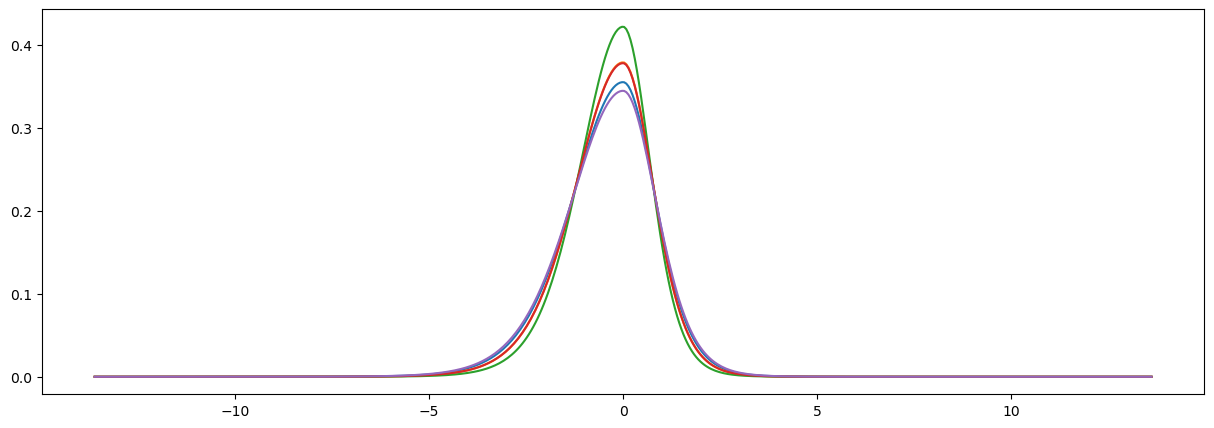

In [ ]:
# # Example usage:
# model = BetaTEGARCH(
#     omega=0.01,
#     phi1=0.95,
#     # phi2=0.9,
#     kappa1=0.01,
#     # kappa2=0.05,
#     kappastar=0.05,
#     df=10,
#     skew=0.8)
# sim = model.simulate(T=500, random_state=200)
# density_df = model.build_density_matrix(sim['sigma'])

# density_df.iloc[:,:5].plot(legend=False, figsize=(15,5))

# Fernandez-Steel Skew-t distribution

In [ ]:
# import numpy as np
# from scipy.stats import t
# from scipy.special import gamma


# class GASSkewT:
#     """
#     GAS(1,1) model with standardized Fernández–Steel skewed Student-t innovations.

#     The model is defined as:

#         Z_t | F_{t-1} ~ g(z | θ_t; ν)

#     where the time-varying parameter is:

#         θ_t = (m_t, ℓ_t, η_t)

#     with:
#         m_t   : conditional mean
#         ℓ_t   : log standard deviation  → σ_t = exp(ℓ_t)
#         η_t   : log asymmetry parameter → a_t = exp(η_t)

#     The conditional density is:

#         g(z | θ_t) = (1 / σ_t) * h((z - m_t) / σ_t | a_t, ν)

#     where h(·) is the standardized Fernández–Steel skewed-t density
#     with zero mean and unit variance.

#     The GAS(1,1) recursion (γ = 0 case) is:

#         θ_{t+1} - θ* = α ∇_t + β (θ_t - θ*)

#     where:
#         ∇_t = ∂ log g(Z_t | θ) / ∂θ evaluated at θ = θ_t

#     Parameters
#     ----------
#     nu : float
#         Degrees of freedom of the Student-t distribution (ν > 2).

#     alpha : (3,3) ndarray
#         Score sensitivity matrix.

#     beta : (3,3) ndarray
#         Persistence matrix.

#     theta_star : (3,) ndarray
#         Unconditional (long-run) parameter.

#     eps : float, optional
#         Step size for numerical differentiation (default: 1e-5).

#     Notes
#     -----
#     - The skewed-t follows Fernández & Steel (1998).
#     - The density is internally standardized to ensure:
#         E[X] = 0 and Var[X] = 1.
#     - This implementation uses numerical differentiation for the score.
#     """

#     def __init__(
#         self,
#         nu: float = 8.0,
#         alpha: np.ndarray = None,
#         beta: np.ndarray = None,
#         theta_star: np.ndarray = None,
#         eps: float = 1e-5,
#     ):
#         self.nu = nu
#         self.eps = eps

#         self.alpha = alpha if alpha is not None else np.diag([0.03, 0.02, 0.015])
#         self.beta = beta if beta is not None else np.diag([0.95, 0.90, 0.85])
#         self.theta_star = (
#             theta_star
#             if theta_star is not None
#             else np.array([0.0, np.log(1.0), np.log(1.0)])
#         )

#     # ============================================================
#     # RAW DISTRIBUTION COMPONENTS
#     # ============================================================

#     @staticmethod
#     def _m1_t(nu: float) -> float:
#         """First absolute moment over positive half-line of Student-t."""
#         return (
#             np.sqrt(nu)
#             * gamma((nu + 1) / 2)
#             / ((nu - 1) * np.sqrt(np.pi) * gamma(nu / 2))
#         )

#     def _raw_moments(self, a: float) -> dict:
#         """Compute raw mean and variance of skewed-t."""
#         nu = self.nu

#         c_a = 2.0 / (a + 1.0 / a)
#         M1 = self._m1_t(nu)
#         V = nu / (nu - 2)

#         mu = c_a * M1 * (a**2 - a**(-2))
#         m2 = c_a * (V / 2) * (a**3 + a**(-3))
#         var = m2 - mu**2

#         return {"mu": mu, "sd": np.sqrt(var)}

#     def _d_fs_raw(self, x, a: float, log=False):
#         """Raw (non-standardized) skewed-t density."""
#         c_a = 2.0 / (a + 1.0 / a)

#         dens = np.where(
#             x < 0,
#             c_a * t.pdf(a * x, df=self.nu),
#             c_a * t.pdf(x / a, df=self.nu),
#         )

#         return np.log(dens) if log else dens

#     def _d_fs_std(self, x, a: float, log=False):
#         """Standardized skewed-t density."""
#         mom = self._raw_moments(a)
#         y = mom["mu"] + mom["sd"] * x

#         logdens = np.log(mom["sd"]) + self._d_fs_raw(y, a, log=True)
#         return logdens if log else np.exp(logdens)

#     def _r_fs_std(self, n: int, a: float):
#         """Random generator for standardized skewed-t."""
#         p_pos = a**2 / (1 + a**2)

#         sign_pos = np.random.rand(n) < p_pos
#         w = np.abs(t.rvs(df=self.nu, size=n))

#         x_raw = np.where(sign_pos, a * w, -w / a)

#         mom = self._raw_moments(a)
#         return (x_raw - mom["mu"]) / mom["sd"]

#     # ============================================================
#     # CONDITIONAL DENSITY
#     # ============================================================

#     def logpdf(self, z, theta):
#         """
#         Log-density log g(z | θ).

#         Parameters
#         ----------
#         z : float or ndarray
#             Observation(s).

#         theta : array_like, shape (3,)
#             Parameter vector (m, ℓ, η).

#         Returns
#         -------
#         float or ndarray
#             Log-density value(s).
#         """
#         m, ell, eta = theta
#         sigma = np.exp(ell)
#         a = np.exp(eta)

#         x = (z - m) / sigma
#         return -ell + self._d_fs_std(x, a, log=True)

#     def rvs(self, n: int, theta):
#         """
#         Generate random draws from g(z | θ).

#         Returns
#         -------
#         ndarray
#         """
#         m, ell, eta = theta
#         sigma = np.exp(ell)
#         a = np.exp(eta)

#         return m + sigma * self._r_fs_std(n, a)

#     # ============================================================
#     # SCORE
#     # ============================================================

#     def score(self, z, theta):
#         """
#         Numerical score ∇ = ∂ log g(z | θ) / ∂θ.

#         Central finite differences.

#         Returns
#         -------
#         ndarray, shape (3,)
#         """
#         theta = np.asarray(theta)
#         grad = np.zeros_like(theta)

#         for j in range(len(theta)):
#             step = self.eps * (1 + abs(theta[j]))

#             theta_plus = theta.copy()
#             theta_minus = theta.copy()

#             theta_plus[j] += step
#             theta_minus[j] -= step

#             lp = self.logpdf(z, theta_plus)
#             lm = self.logpdf(z, theta_minus)

#             grad[j] = (lp - lm) / (2 * step)

#         return grad

#     # ============================================================
#     # SIMULATION
#     # ============================================================

#     def simulate(self, T: int, theta_init=None, random_state=None):
#         """
#         Simulate a GAS(1,1) trajectory.

#         Parameters
#         ----------
#         T : int
#             Number of observations.

#         theta_init : ndarray, optional
#             Initial parameter θ_1. Defaults to θ*.

#         random_state : int, optional
#             Seed for reproducibility.

#         Returns
#         -------
#         dict
#             Keys:
#             - Z           : observations
#             - theta       : parameter path
#             - mean        : m_t
#             - sd          : σ_t
#             - asymmetry   : a_t
#             - score       : score sequence
#         """
#         if random_state is not None:
#             np.random.seed(random_state)

#         theta_init = (
#             theta_init.copy()
#             if theta_init is not None
#             else self.theta_star.copy()
#         )

#         k = len(self.theta_star)

#         Z = np.zeros(T)
#         theta_path = np.zeros((T + 1, k))
#         scores = np.zeros((T, k))

#         theta_path[0] = theta_init

#         for t in range(T):
#             theta_t = theta_path[t]

#             Z[t] = self.rvs(1, theta_t)[0]

#             grad = self.score(Z[t], theta_t)
#             scores[t] = grad

#             theta_path[t + 1] = (
#                 self.theta_star
#                 + self.alpha @ grad
#                 + self.beta @ (theta_t - self.theta_star)
#             )

#         return {
#             "Z": Z,
#             "theta": theta_path[:-1],
#             "mean": theta_path[:-1, 0],
#             "sd": np.exp(theta_path[:-1, 1]),
#             "asymmetry": np.exp(theta_path[:-1, 2]),
#             "score": scores,
#         }
    
#     def conditional_densities(self, grid, theta_path, log=False):
#         """
#         Vectorized version over grid (faster).
#         """
#         grid = np.asarray(grid)
#         theta_path = np.asarray(theta_path)

#         m = theta_path[:, 0][:, None]
#         ell = theta_path[:, 1][:, None]
#         eta = theta_path[:, 2][:, None]

#         sigma = np.exp(ell)
#         a = np.exp(eta)

#         x = (grid[None, :] - m) / sigma

#         logdens = -ell + self._d_fs_std(x, a, log=True)

#         dens = pd.DataFrame(logdens if log else np.exp(logdens)).T.set_index(grid)

#         return dens

In [2]:
class SkewStudentT:
    """
    Implements the Fernández–Steel skewed Student-t density.
    
    Mathematical definition:
    h_tilde(x | a, nu) = [2 / (a + a^-1)] * [b_nu(ax) I(x < 0) + b_nu(x/a) I(x >= 0)]

    Example
    -------
    >>> x = np.linspace(-3, 3, 100)
    >>> density = SkewStudentT.density_raw(x, a=1.5, nu=8.0)
    >>> moments = SkewStudentT.raw_moments(a=1.5, nu=8.0)
    """
    
    @staticmethod
    def M1_nu(nu: float) -> float:
        """First absolute moment of Student-t over the positive half-line."""
        return (np.sqrt(nu) * gamma((nu + 1) / 2)) / \
               ((nu - 1) * np.sqrt(np.pi) * gamma(nu / 2))

    @staticmethod
    def moments(a: float, nu: float) -> dict:
        """Compute mean and variance of the non-standardized skewed-t."""
        c_a = 2.0 / (a + 1.0 / a)
        m1 = SkewStudentT.M1_nu(nu)
        v = nu / (nu - 2.0)

        mu = c_a * m1 * (a**2 - a**(-2))
        m2 = c_a * (v / 2.0) * (a**3 + a**(-3))
        var = m2 - mu**2
        
        return mu, np.sqrt(var)

    @staticmethod
    def density(x, a: float, nu: float, log: bool = False):
        """Raw (non-standardized) Fernández-Steel skewed-t density."""
        c_a = 2.0 / (a + 1.0 / a)
        
        # Logic matching R's ifelse(x < 0, ...)
        dens = np.where(
            x < 0,
            c_a * t.pdf(a * x, df=nu),
            c_a * t.pdf(x / a, df=nu)
        )
        return np.log(dens) if log else dens

In [3]:
class StandardizedSkewStudentT:
    """
    Standardized Fernández–Steel skewed-t density (Mean=0, Var=1)[cite: 1].

    Example
    -------
    >>> dist = StandardizedSkewStudentT(nu=8.0)
    >>> sample = dist.rvs(n=1000, a=1.5)
    """
    def __init__(
                 self,
                 a,
                 nu: float = 8.0
                 ):
        self.a  = a
        self.nu = nu
        self.mu, self.sigma = SkewStudentT.moments(a=self.a, nu=self.nu)

    def density(self, x, log=False):
        """Standardized skewed-t density."""
        mu, sigma = SkewStudentT.moments(a=self.a, nu=self.nu)
        y = mu + sigma * x

        logdens = np.log(sigma) + SkewStudentT.density(y, a=self.a, nu=self.nu, log=True)
        # logdens = pd.Series(logdens, index=x)
        return logdens if log else np.exp(logdens)
    
    def random_numbers(self, n: int):
        """Random generator for standardized skewed t distribution."""
        p_pos = self.a**2 / (1 + self.a**2)

        sign_pos = np.random.rand(n) < p_pos
        w = np.abs(t.rvs(df=self.nu, size=n))

        x_raw = np.where(sign_pos, self.a * w, -w / self.a)
        x_raw = pd.Series(x_raw)

        return (x_raw - self.mu) / self.sigma


In [8]:
class GasModel:
    def __init__(
            self,
            nu = 8,
            theta_star = None,
            alpha = None,
            beta = None,
            eps: float = 1e-5,
                 ):
        self.nu = nu
        self.eps = eps
        self.theta_star = (
            theta_star if theta_star is not None
                else np.array([0.0, np.log(1.0), np.log(1.0)])
        )
        self.alpha = alpha if alpha is not None else np.diag([0.03, 0.02, 0.015])
        self.beta = beta if beta is not None else np.diag([0.95, 0.90, 0.85])

    # ============================================================
    # CONDITIONAL DENSITY
    # ============================================================
        
    def logpdf(self, z, theta):
        """
        Log-density log g(z | θ).

        Parameters
        ----------
        z : float or ndarray
            Observation(s).

        theta : array_like, shape (3,)
            Parameter vector (m, ℓ, η).

        Returns
        -------
        float or ndarray
            Log-density value(s).
        """
        m, ell, eta = theta
        sigma = np.exp(ell)
        a = np.exp(eta)

        x = (z - m) / sigma
        skt = StandardizedSkewStudentT(a=a, nu=self.nu)

        return -ell + skt.density(x, log=True)

    def rvs(self, n: int, theta):
        """
        Generate random draws from g(z | θ).

        Returns
        -------
        ndarray
        """
        m, ell, eta = theta
        sigma = np.exp(ell)
        a = np.exp(eta)

        skt = StandardizedSkewStudentT(a=a)

        return m + sigma * skt.random_numbers(n)

    # ============================================================
    # SCORE
    # ============================================================

    def score(self, z, theta):
        """
        Numerical score ∇ = ∂ log g(z | θ) / ∂θ.

        Central finite differences.

        Returns
        -------
        ndarray, shape (3,)
        """
        theta = np.asarray(theta)
        grad = np.zeros_like(theta)

        for j in range(len(theta)):
            step = self.eps * (1 + abs(theta[j]))

            theta_plus = theta.copy()
            theta_minus = theta.copy()

            theta_plus[j] += step
            theta_minus[j] -= step

            lp = self.logpdf(z, theta_plus)
            lm = self.logpdf(z, theta_minus)

            grad[j] = (lp - lm) / (2 * step)

        return grad

    # ============================================================
    # SIMULATION
    # ============================================================

    def simulate(self, T: int, theta_init=None, random_state=None):
        """
        Simulate a GAS(1,1) trajectory.

        Parameters
        ----------
        T : int
            Number of observations.

        theta_init : ndarray, optional
            Initial parameter θ_1. Defaults to θ*.

        random_state : int, optional
            Seed for reproducibility.

        Returns
        -------
        dict
            Keys:
            - Z           : observations
            - theta       : parameter path
            - mean        : m_t
            - sd          : σ_t
            - asymmetry   : a_t
            - score       : score sequence
        """
        if random_state is not None:
            np.random.seed(random_state)

        theta_init = (
            theta_init.copy()
            if theta_init is not None
            else self.theta_star.copy()
        )

        k = len(self.theta_star)

        Z = np.zeros(T)
        theta_path = np.zeros((T + 1, k))
        scores = np.zeros((T, k))

        theta_path[0] = theta_init

        for t in range(T):
            theta_t = theta_path[t]

            Z[t] = self.rvs(1, theta_t)[0]

            grad = self.score(Z[t], theta_t)
            scores[t] = grad

            theta_path[t + 1] = (
                self.theta_star
                + self.alpha @ grad
                + self.beta @ (theta_t - self.theta_star)
            )

        return {
            "Z": Z,
            "theta": theta_path[:-1],
            "mean": theta_path[:-1, 0],
            "sd": np.exp(theta_path[:-1, 1]),
            "asymmetry": np.exp(theta_path[:-1, 2]),
            "score": scores,
        }
    
    def conditional_densities(self, grid, theta_path, log=False):
        """
        Vectorized version over grid (faster).
        """
        grid = np.asarray(grid)
        theta_path = np.asarray(theta_path)

        m = theta_path[:, 0][:, None]
        ell = theta_path[:, 1][:, None]
        eta = theta_path[:, 2][:, None]

        sigma = np.exp(ell)
        a = np.exp(eta)

        x = (grid[None, :] - m) / sigma

        skt = StandardizedSkewStudentT(a=a, nu=self.nu)
        logdens = -ell + skt.density(x, log=True)

        dens = pd.DataFrame(logdens if log else np.exp(logdens)).T.set_index(grid)

        return dens

In [38]:
x = np.linspace(-10, 10, 1000)

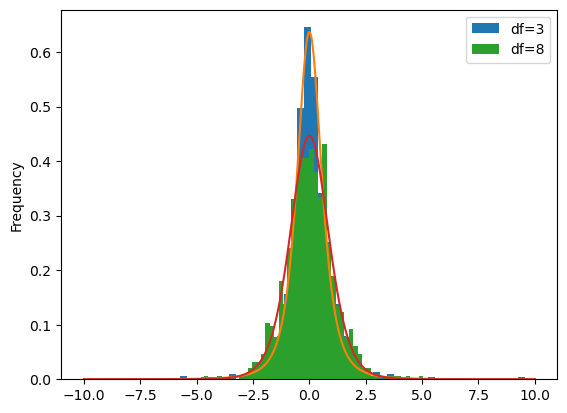

In [61]:
skt = StandardizedSkewStudentT(a=1, nu=3)
skt_dens = skt.density(x)
skt_sample = skt.random_numbers(1000)
skt_sample.plot(kind="hist", bins=50, density=True, label="df=3")
pd.Series(skt_dens, index=x).plot()

skt = StandardizedSkewStudentT(a=1, nu=8)
skt_dens = skt.density(x)
skt_sample = skt.random_numbers(1000)
skt_sample.plot(kind="hist", bins=50, density=True, label="df=8")
pd.Series(skt_dens, index=x).plot()

plt.legend()

In [62]:
alpha  = np.diag([0.03, 0.02, 0.015])
beta   = np.diag([0.95, 0.90, 0.85])
gm = GasModel(alpha=alpha, beta=beta)
sim_results = gm.simulate(T=100, random_state=123)
sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])

<Axes: >

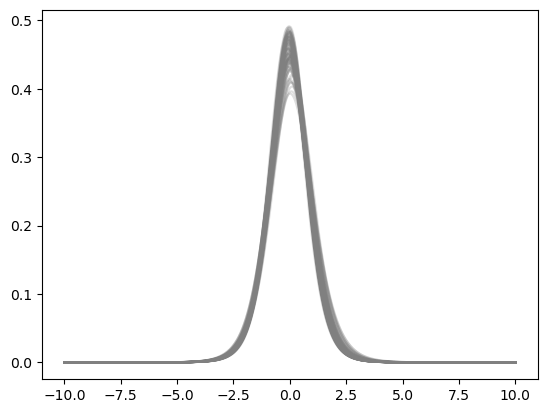

In [63]:
sim_density.plot(legend=False, color="gray", alpha=0.25)

<Axes: >

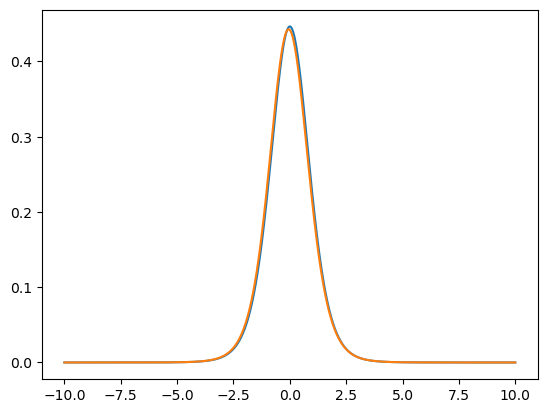

In [64]:
sim_density.iloc[:,:2].plot(legend=False)

In [ ]:
# Define scenarios
simulation_scenarios = {
    "volatility_clustering": {
        "alpha": np.diag([0.02, 0.05, 0.01]),
        "beta": np.diag([0.80, 0.98, 0.85]),
        "theta_star": np.array([0.0, np.log(1.2), np.log(1.0)]),
        "description": "High persistence in volatility (ell); simulates financial 'calm before the storm'."
    },
    "regime_shifter": {
        "alpha": np.diag([0.01, 0.01, 0.15]),
        "beta": np.diag([0.95, 0.95, 0.70]),
        "theta_star": np.array([0.0, 0.0, 0.0]),
        "description": "High sensitivity to skewness (eta); the distribution shape 'flips' rapidly."
    },
    "mean_reverting_jumps": {
        "alpha": np.diag([0.20, 0.02, 0.01]),
        "beta": np.diag([0.40, 0.95, 0.90]),
        "theta_star": np.array([0.0, 0.0, 0.0]),
        "description": "Reactive mean (m) that spikes on shocks but reverts quickly to center."
    },
    "structural_instability": {
        "alpha": np.diag([0.005, 0.005, 0.005]),
        "beta": np.diag([0.99, 0.99, 0.99]),
        "theta_star": np.array([0.0, 0.0, 0.0]),
        "description": "Extreme persistence; parameters wander far from theta_star for long periods."
    }
}

Running Scenario: volatility_clustering
Details: High persistence in volatility (ell); simulates financial 'calm before the storm'.


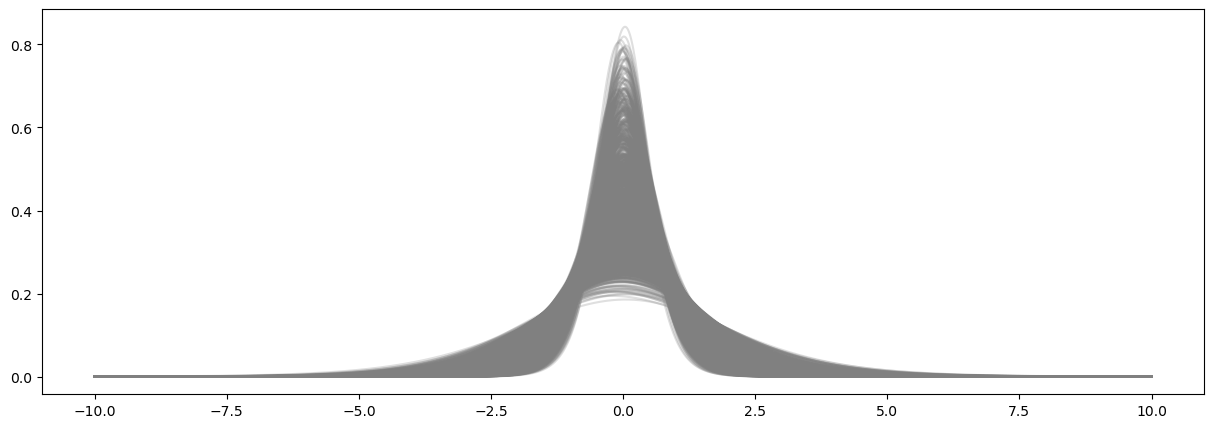

Running Scenario: regime_shifter
Details: High sensitivity to skewness (eta); the distribution shape 'flips' rapidly.


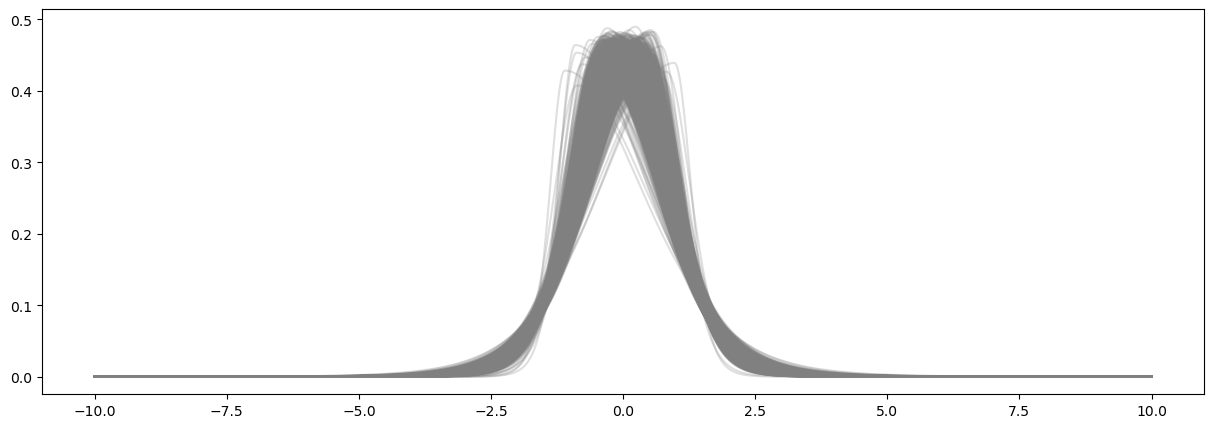

Running Scenario: mean_reverting_jumps
Details: Reactive mean (m) that spikes on shocks but reverts quickly to center.


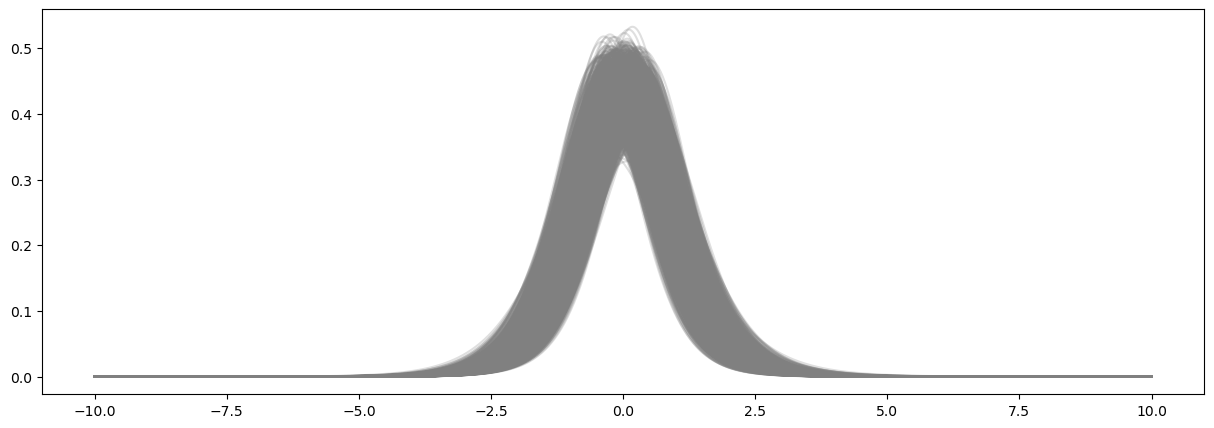

Running Scenario: structural_instability
Details: Extreme persistence; parameters wander far from theta_star for long periods.


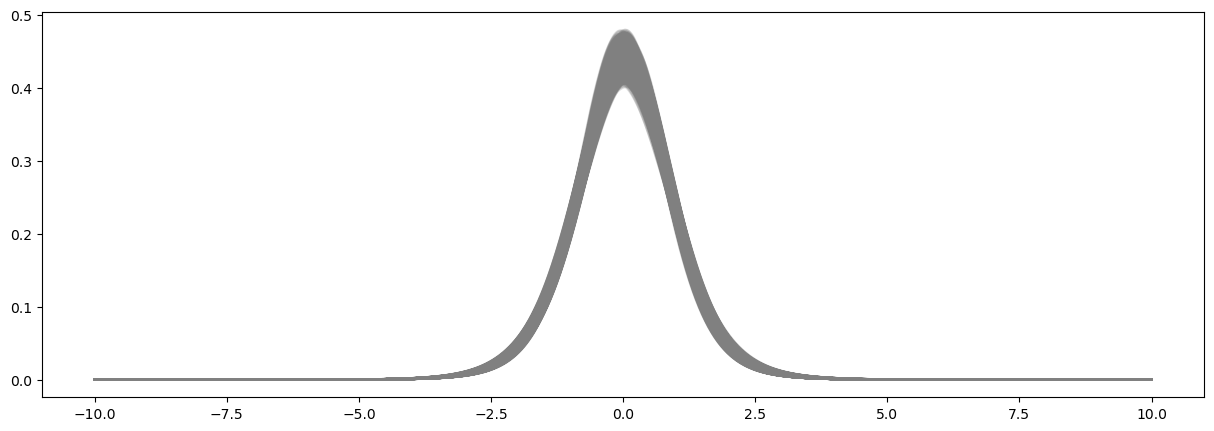

In [68]:
x = np.linspace(-10, 10, 1000)
for scenario in simulation_scenarios:
    # 1. Pick a scenario
    params = simulation_scenarios[scenario]

    # 2. Initialize Model (assuming you refactored to take these as init args)
    # We remove 'description' since gasModel doesn't expect it
    model_args = {k: v for k, v in params.items() if k != 'description'}
    gm = GasModel(**model_args)

    # 3. Run and Visualize
    print(f"Running Scenario: {scenario}")
    print(f"Details: {params['description']}")

    sim_results = gm.simulate(T=1500, random_state=42)
    sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])

    plt.figure(figsize=(15,5))
    plt.plot(sim_density, color="gray", alpha=0.25)
    plt.show()
    